# `preion.forecast` tutorial (for auto-spectra)

End-to-end walk-through of the auto forecast pipeline: build a config, generate
mock kSZ/tau/BB data with `make_autos_datapoints`, run a (short, for this notebook)
`emcee` MCMC with `run_mcmc`, then read back and diagnose the
chain the way `preion-read-mcmc` does. See `forecast_tutorial_cross.ipynb`
for the tau x 21cm cross-correlation equivalent.

In [1]:
import shutil
import tempfile
from pathlib import Path
import numpy as np

from preion.forecast import config, datapoints, mcmc, read_mcmc

%matplotlib inline

## 1. Load a config

`config.load_config` reads a YAML file and fills in defaults matching the
values that used to be hardcoded in `run_mcmc_cv_limited_new.py`. We start
from the packaged example config and shrink it to a tiny, fast run in a
scratch directory.

In [2]:
run_dir = Path(tempfile.mkdtemp(prefix='preion_forecast_tutorial_'))

In [3]:
cfg = config.load_config('../configs/config_tutorial_mcmc_autos.yaml')
cfg['output_dir'] = str(run_dir)
print(cfg)

{'label': 'mcmc_tutorial_autos', 'title': 'Tutorial forecast', 'data': 'all', 'theta_true': [7.0, 1.5, 3.7, 0.1], 'log_kappa': True, 'niterations': 10, 'nwalkers': 8, 'fsky': 1.0, 'use_ksz_emulator': False, 'overwrite': True, 'plot': False, 'progress': True, 'telescopes': None, 'output_dir': '/tmp/preion_forecast_tutorial_7yhgs5zf', 'ells': {'tau': {'start': 100, 'stop': 5000, 'step': 100}, 'ksz': {'start': 1000, 'stop': 8000, 'step': 500}, 'bb': {'start': 10, 'stop': 1000, 'num': 50}}}


## 2. Generate mock data

In the MCMC framework, the method `mcmc.get_or_make_datapoints` will automatically read cached
datapoints back from disk if they already exist or re-compute them. Alternatively, one can use
`make_autos_datapoints` to generate the datapoints directly. If `telescopes=None`, then the forecast is
cosmic-variance limited.

In [4]:
# ells_tau, ells_ksz, ells_bb
# note that the ells are the edges of the multipole bins to consider in the forecast
ells = np.array([[100, 200], [1000, 2000], [100, 200]])
tau_ps, ksz_ps, bb_ps, cov_tau, cov_ksz, cov_bb = datapoints.make_autos_datapoints(
    cfg['theta_true'], telescopes=cfg['telescopes'], ells=ells,
    use_ksz_emulator=cfg['use_ksz_emulator'],
)  # takes a couple minutes to run
print('ksz_ps:', ksz_ps)

ksz_ps: [0.8245559  1.27484561]


## 3. Run the MCMC

Rather than regenerating mock data (which reruns CAMB) every time, we load a
pre-computed cosmic-variance-limited dataset shipped with the package via
`datapoints.load_autos_datapoints(_PACKAGED_DATA_DIR, _PACKAGED_LABEL)`, then
`mcmc.run_mcmc(datapoints_dict, cfg)` runs `emcee` against it and writes the
chain to `{output_dir}/backends/`.

Status/timing/diagnostic messages are written to a logfile at
`{output_dir}/{label}.log`.

In [4]:
from preion.forecast.datapoints import _PACKAGED_DATA_DIR, _PACKAGED_LABEL

datapoints_dict = datapoints.load_autos_datapoints(_PACKAGED_DATA_DIR, _PACKAGED_LABEL)

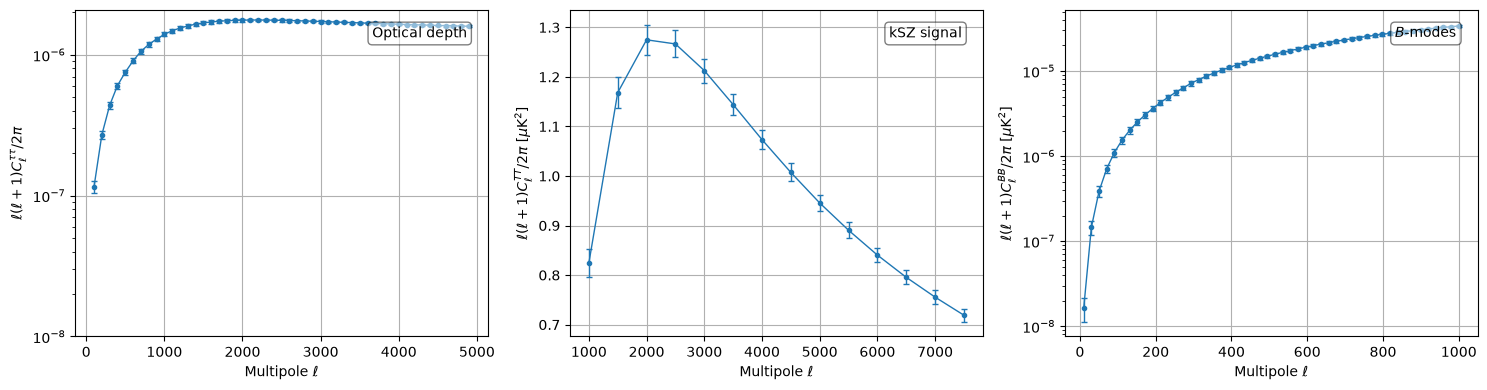

In [5]:
fig, axes = mcmc.plot_autos_obs(cfg, datapoints=datapoints_dict)

In [ ]:
sampler = mcmc.run_mcmc(datapoints_dict, cfg)

 20%|██        | 2/10 [00:59<03:55, 29.49s/it]

## 4. Read back and diagnose the chain

This mirrors what `preion-read-mcmc configs/config_tutorial_mcmc_autos.yaml` does on the
command line: load the chain, compute convergence diagnostics, flatten the
post-burn-in samples, and plot a corner/trace/posterior-predictive figure.

In [ ]:
sampler = read_mcmc.load_chain(cfg)
diagnostics = read_mcmc.convergence_diagnostics(sampler)
print(f"Auto-correlation time: {diagnostics['endtau']:.2f}. Converged: {diagnostics['converged']}.")
print(f"burnin = {diagnostics['burnin']} steps")

Auto-correlation time: 0.90. Converged: False.
burnin = 1 steps


In [ ]:
flatsamples, logps = read_mcmc.get_flat_samples(sampler, diagnostics['burnin'])
truths = read_mcmc._theta_true(cfg)
labels = read_mcmc._theta_labels(cfg)
summary = read_mcmc.summarize(flatsamples, truths, read_mcmc.PARAM_NAMES)

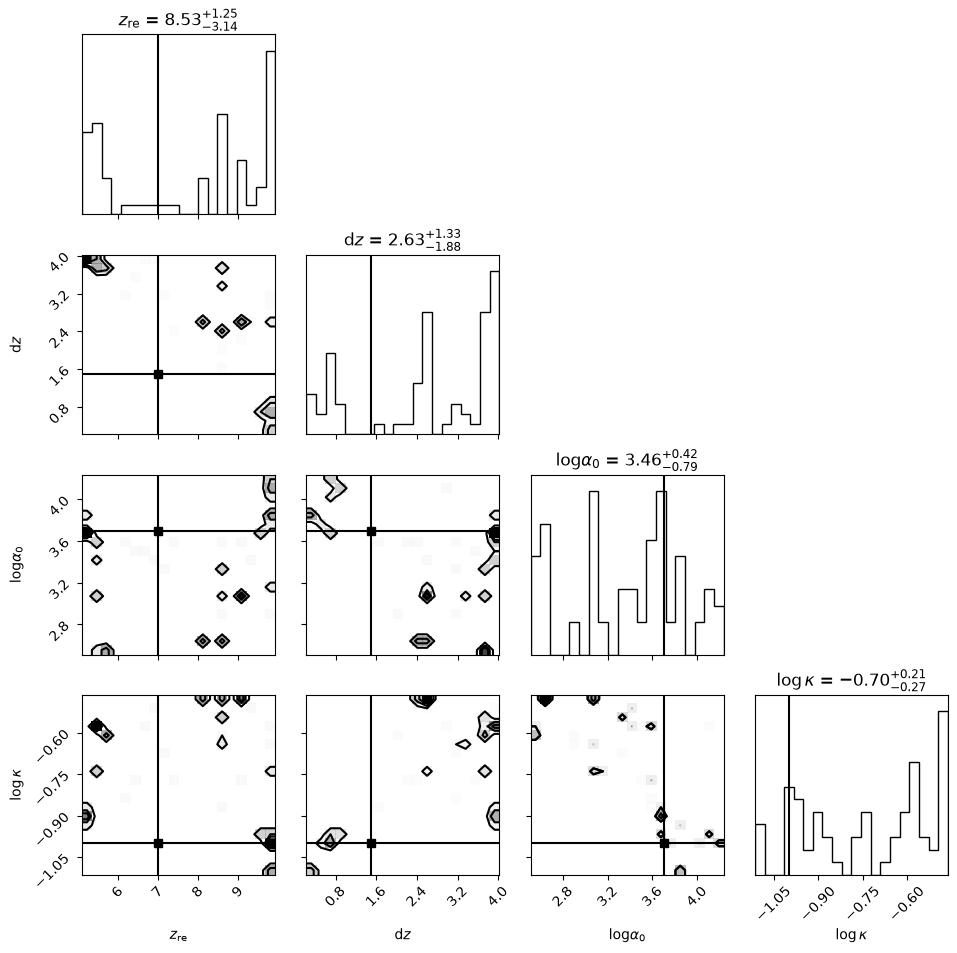

In [ ]:
fig_corner = read_mcmc.plot_corner(flatsamples, truths, labels)

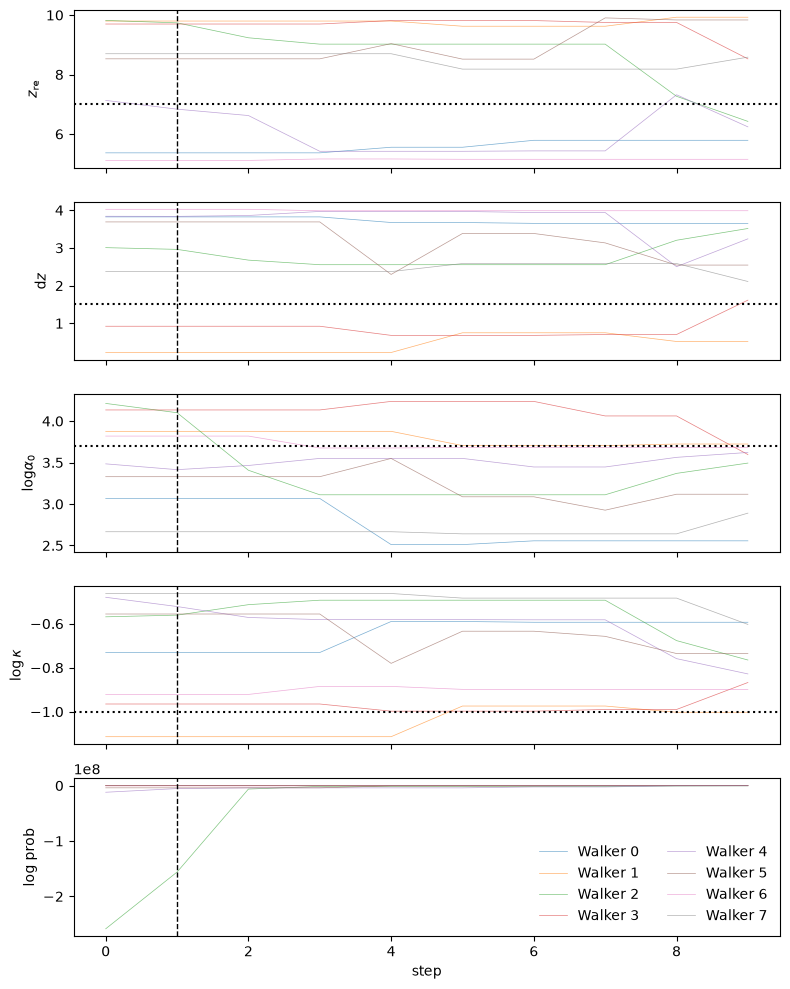

In [ ]:
fig_trace = read_mcmc.plot_trace(sampler, truths, labels, diagnostics['burnin'])

In [ ]:
fig_pp = read_mcmc.plot_autos_models(sampler, datapoints_dict, diagnostics['burnin'])

In [ ]:
shutil.rmtree(run_dir, ignore_errors=True)